In [ ]:
import numpy as np
import pandas as pd
data = {
    'Time': ['10:00', '10:01', '10:02', '10:03', '10:04', '10:05', '10:06', '10:07', '10:08', '10:09', '10:10', '10:11'],
    'Room': ['C1.3.101'] * 12,
    'Temp_C': [21.5, 21.7, None, 22.1, 22.3, 22.5, 22.6, 22.7, 22.9, 23.1, 23.2, 23.3],
    'CO2_ppm': [620, 650, 690, 720, None, 780, 810, 830, 850, 900, 920, 950],
    'Occupancy': [18, 20, 22, 24, 25, 27, 29, None, 31, 33, 35, 37],
    'Power_kW': [3.2, 3.4, 3.5, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.1, 5.4, 5.7]
}

df = pd.DataFrame(data)
print("--- Original DataFrame ---")
display(df)

--- Original DataFrame ---


,Time,Room,Temp_C,CO2_ppm,Occupancy,Power_kW
0,10:00,C1.3.101,21.5,620.0,18.0,3.2
1,10:01,C1.3.101,21.7,650.0,20.0,3.4
2,10:02,C1.3.101,NaN,690.0,22.0,3.5
3,10:03,C1.3.101,22.1,720.0,24.0,3.8
4,10:04,C1.3.101,22.3,NaN,25.0,4.0
5,10:05,C1.3.101,22.5,780.0,27.0,4.2
6,10:06,C1.3.101,22.6,810.0,29.0,4.4
7,10:07,C1.3.101,22.7,830.0,NaN,4.6
8,10:08,C1.3.101,22.9,850.0,31.0,4.8
9,10:09,C1.3.101,23.1,900.0,33.0,5.1


## Part A — Data Quality & Cleaning
Handling missing values using linear interpolation for temperature and CO2, and forward-fill for occupancy.

In [ ]:
df['Temp_C'] = df['Temp_C'].interpolate(method='linear')
df['CO2_ppm'] = df['CO2_ppm'].interpolate(method='linear')
df['Occupancy'] = df['Occupancy'].ffill()

print("--- Cleaned DataFrame ---")
display(df)

--- Cleaned DataFrame ---


,Time,Room,Temp_C,CO2_ppm,Occupancy,Power_kW
0,10:00,C1.3.101,21.5,620.0,18.0,3.2
1,10:01,C1.3.101,21.7,650.0,20.0,3.4
2,10:02,C1.3.101,21.9,690.0,22.0,3.5
3,10:03,C1.3.101,22.1,720.0,24.0,3.8
4,10:04,C1.3.101,22.3,750.0,25.0,4.0
5,10:05,C1.3.101,22.5,780.0,27.0,4.2
6,10:06,C1.3.101,22.6,810.0,29.0,4.4
7,10:07,C1.3.101,22.7,830.0,29.0,4.6
8,10:08,C1.3.101,22.9,850.0,31.0,4.8
9,10:09,C1.3.101,23.1,900.0,33.0,5.1


## Part B — Streaming Window Statistics
Calculating 3-minute rolling means for temperature, CO2, and power consumption.

In [ ]:
df['Temp_rolling'] = df['Temp_C'].rolling(window=3).mean()
df['CO2_rolling'] = df['CO2_ppm'].rolling(window=3).mean()
df['Power_rolling'] = df['Power_kW'].rolling(window=3).mean()

print("--- 3-Minute Rolling Window Statistics ---")
display(df[['Time', 'Temp_rolling', 'CO2_rolling', 'Power_rolling']].dropna())

--- 3-Minute Rolling Window Statistics ---


,Time,Temp_rolling,CO2_rolling,Power_rolling
2,10:02,21.700000,653.333333,3.366667
3,10:03,21.900000,686.666667,3.566667
4,10:04,22.100000,720.000000,3.766667
5,10:05,22.300000,750.000000,4.000000
6,10:06,22.466667,780.000000,4.200000
7,10:07,22.600000,806.666667,4.400000
8,10:08,22.733333,830.000000,4.600000
9,10:09,22.900000,860.000000,4.833333
10,10:10,23.066667,890.000000,5.100000
11,10:11,23.200000,923.333333,5.400000


## Part C — Feature Engineering
Creating occupancy density, energy per student, and comfort flags.

In [ ]:
df['occupancy_density'] = df['Occupancy'] / 40
df['energy_per_student'] = df['Power_kW'] / df['Occupancy']
df['comfort_flag'] = (df['CO2_ppm'] <= 1000) & (df['Temp_C'].between(20, 24))

print("--- Feature Engineering Results ---")
display(df[['Time', 'occupancy_density', 'energy_per_student', 'comfort_flag']])

--- Feature Engineering Results ---


,Time,occupancy_density,energy_per_student,comfort_flag
0,10:00,0.450,0.177778,True
1,10:01,0.500,0.170000,True
2,10:02,0.550,0.159091,True
3,10:03,0.600,0.158333,True
4,10:04,0.625,0.160000,True
5,10:05,0.675,0.155556,True
6,10:06,0.725,0.151724,True
7,10:07,0.725,0.158621,True
8,10:08,0.775,0.154839,True
9,10:09,0.825,0.154545,True


## Part D — Statistical Analysis
Computing descriptive statistics and correlations.

In [5]:
# Part D implementation
print(f"Temperature Mean: {df['Temp_C'].mean():.2f}°C")
print(f"Temperature Median: {df['Temp_C'].median():.2f}°C")
print(f"Temperature Min: {df['Temp_C'].min():.2f}°C")
print(f"Temperature Max: {df['Temp_C'].max():.2f}°C")

print(f"\nCO2 Mean: {df['CO2_ppm'].mean():.2f} ppm")
print(f"CO2 Max: {df['CO2_ppm'].max():.2f} ppm")

max_power_time = df.loc[df['Power_kW'].idxmax(), 'Time']
max_power_val = df['Power_kW'].max()
print(f"\nTime with highest power consumption: {max_power_time} ({max_power_val} kW)")

correlation = df['Occupancy'].corr(df['Power_kW'])
print(f"Correlation between occupancy and power: {correlation:.4f}")

Temperature Mean: 22.48°C
Temperature Median: 22.55°C
Temperature Min: 21.50°C
Temperature Max: 23.30°C

CO2 Mean: 789.17 ppm
CO2 Max: 950.00 ppm

Time with highest power consumption: 10:11 (5.7 kW)
Correlation between occupancy and power: 0.9946


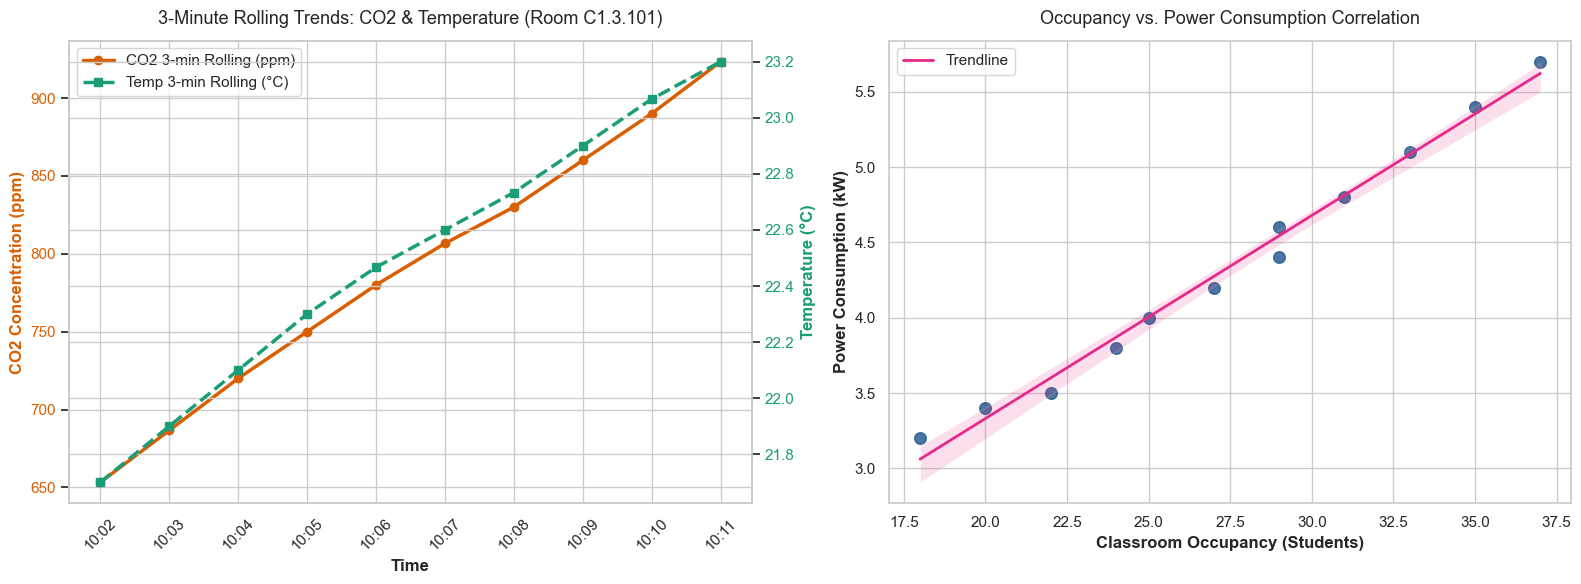

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1 = axes[0]
color_co2 = "#d95f02"
color_temp = "#1b9e77"
line1 = ax1.plot(
    df["Time"],
    df["CO2_rolling"],
    color=color_co2,
    marker="o",
    linewidth=2.5,
    label="CO2 3-min Rolling (ppm)",
)
ax1.set_xlabel("Time", fontsize=12, fontweight="bold")
ax1.set_ylabel("CO2 Concentration (ppm)", color=color_co2, fontsize=12, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=color_co2)
ax1.tick_params(axis="x", rotation=45)

ax1_twin = ax1.twinx()
line2 = ax1_twin.plot(
    df["Time"],
    df["Temp_rolling"],
    color=color_temp,
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label="Temp 3-min Rolling (°C)",
)
ax1_twin.set_ylabel("Temperature (°C)", color=color_temp, fontsize=12, fontweight="bold")
ax1_twin.tick_params(axis="y", labelcolor=color_temp)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True)
ax1.set_title("3-Minute Rolling Trends: CO2 & Temperature (Room C1.3.101)", fontsize=13, pad=12)

ax2 = axes[1]
sns.regplot(
    data=df,
    x="Occupancy",
    y="Power_kW",
    ax=ax2,
    color="#2b5c8f",
    scatter_kws={"s": 70, "alpha": 0.85},
    line_kws={"color": "#e7298a", "linewidth": 2, "label": "Trendline"},
)

ax2.set_xlabel("Classroom Occupancy (Students)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Power Consumption (kW)", fontsize=12, fontweight="bold")
ax2.set_title("Occupancy vs. Power Consumption Correlation", fontsize=13, pad=12)
ax2.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()